# Cashew Nut Leaf Disease Detection
This notebook trains a model to classify cashew nut leaves into 5 categories: anthracnose, gumosis, healthy, leaf miner, and red rust.

**Model:** MobileNetV2

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
import os

print(tf.__version__)

# Define parameters
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
BASE_DIR = 'Data set'

# Set up datasets
train_dataset = keras.utils.image_dataset_from_directory(
    os.path.join(BASE_DIR, 'train'),
    shuffle=True,
    batch_size=BATCH_SIZE,
    image_size=IMG_SIZE
)

val_dataset = keras.utils.image_dataset_from_directory(
    os.path.join(BASE_DIR, 'val'),
    shuffle=True,
    batch_size=BATCH_SIZE,
    image_size=IMG_SIZE
)

test_dataset = keras.utils.image_dataset_from_directory(
    os.path.join(BASE_DIR, 'test'),
    shuffle=False,
    batch_size=BATCH_SIZE,
    image_size=IMG_SIZE
)

class_names = train_dataset.class_names
print("Classes:", class_names)

I0000 00:00:1774860705.533025  157625 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1774860705.662692  157625 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1774860709.291708  157625 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


2.21.0
Found 6549 files belonging to 5 classes.


E0000 00:00:1774860711.912026  157625 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Found 6549 files belonging to 5 classes.
Found 6549 files belonging to 5 classes.
Classes: ['anthracnose', 'gumosis', 'healthy', 'leaf miner', 'red rust']


In [ ]:
# Optimize data loading performance
AUTOTUNE = tf.data.AUTOTUNE

train_dataset = train_dataset.prefetch(buffer_size=AUTOTUNE)
val_dataset = val_dataset.prefetch(buffer_size=AUTOTUNE)
test_dataset = test_dataset.prefetch(buffer_size=AUTOTUNE)

# Data augmentation to prevent overfitting
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.2),
])

# Create the base model from the pre-trained model MobileNet V2
IMG_SHAPE = IMG_SIZE + (3,)
base_model = tf.keras.applications.MobileNetV2(
    input_shape=IMG_SHAPE,
    include_top=False,
    weights='imagenet'
)

# Freeze the base model (you can optionally unfreeze and fine-tune later)
base_model.trainable = False

# Build model architecture
inputs = tf.keras.Input(shape=IMG_SHAPE)
x = data_augmentation(inputs)

# MobileNetV2 requires pixels in [-1, 1], application preprocess_input does this
x = tf.keras.applications.mobilenet_v2.preprocess_input(x)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.2)(x)
outputs = layers.Dense(len(class_names))(x)

model = tf.keras.Model(inputs, outputs)

# Compile
base_learning_rate = 0.0001
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=base_learning_rate),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 5)              │         6,405 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,264,389 (8.64 MB)

 Trainable params: 6,405 (25.02 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

205/205 ━━━━━━━━━━━━━━━━━━━━ 324s 2s/step - accuracy: 0.3776 - loss: 1.6499
Initial loss: 1.6499199867248535
Initial validation accuracy: 0.37761491537094116
Epoch 1/10
205/205 ━━━━━━━━━━━━━━━━━━━━ 654s 3s/step - accuracy: 0.5401 - loss: 1.1206 - val_accuracy: 0.7439 - val_loss: 0.7441
Epoch 2/10
205/205 ━━━━━━━━━━━━━━━━━━━━ 651s 3s/step - accuracy: 0.7345 - loss: 0.7068 - val_accuracy: 0.8279 - val_loss: 0.5356
Epoch 3/10
205/205 ━━━━━━━━━━━━━━━━━━━━ 639s 3s/step - accuracy: 0.8087 - loss: 0.5500 - val_accuracy: 0.8589 - val_loss: 0.4422
Epoch 4/10
205/205 ━━━━━━━━━━━━━━━━━━━━ 653s 3s/step - accuracy: 0.8340 - loss: 0.4825 - val_accuracy: 0.8739 - val_loss: 0.3912
Epoch 5/10
205/205 ━━━━━━━━━━━━━━━━━━━━ 403s 2s/step - accuracy: 0.8487 - loss: 0.4366 - val_accuracy: 0.8817 - val_loss: 0.3591
Epoch 6/10
205/205 ━━━━━━━━━━━━━━━━━━━━ 295s 1s/step - accuracy: 0.8633 - loss: 0.3994 - val_accuracy: 0.8901 - val_loss: 0.3344
Epoch 7/10
205/205 ━━━━━━━━━━━━━━━━━━━━ 296s 1s/step - accuracy: 0.8

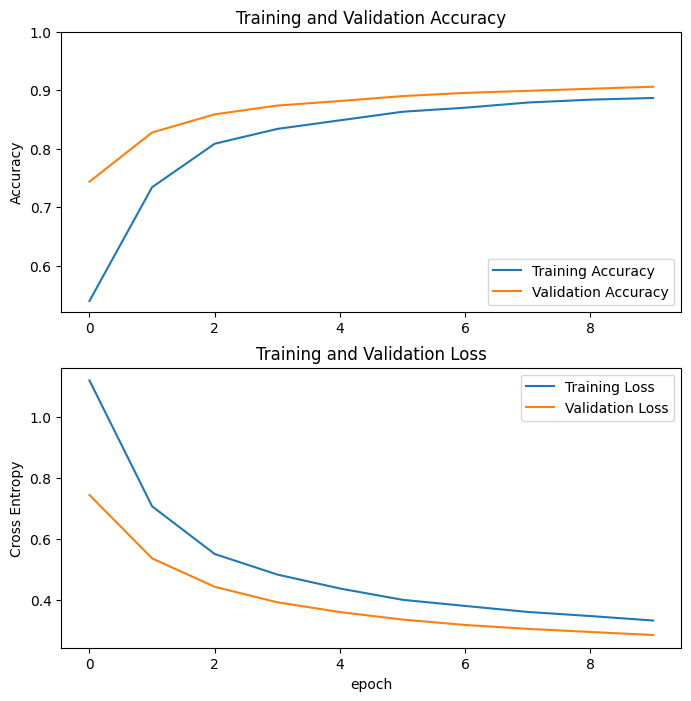

205/205 ━━━━━━━━━━━━━━━━━━━━ 306s 1s/step - accuracy: 0.9061 - loss: 0.2838
Test accuracy: 0.9060925245285034


In [ ]:
# Train the top layer
initial_epochs = 10

loss0, accuracy0 = model.evaluate(val_dataset)
print("Initial loss:", loss0)
print("Initial validation accuracy:", accuracy0)

history = model.fit(
    train_dataset,
    epochs=initial_epochs,
    validation_data=val_dataset,
    callbacks=[
        keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
    ]
)

# Plot Training Progress
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

plt.figure(figsize=(8, 8))
plt.subplot(2, 1, 1)
plt.plot(acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.ylabel('Accuracy')
plt.ylim([min(plt.ylim()),1])
plt.title('Training and Validation Accuracy')

plt.subplot(2, 1, 2)
plt.plot(loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.ylabel('Cross Entropy')
plt.title('Training and Validation Loss')
plt.xlabel('epoch')
plt.show()

# Final Evaluation on the test set
test_loss, test_acc = model.evaluate(test_dataset)
print('Test accuracy:', test_acc)

# Save the model
model.save("cashew_nut_disease_model.keras")

1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step


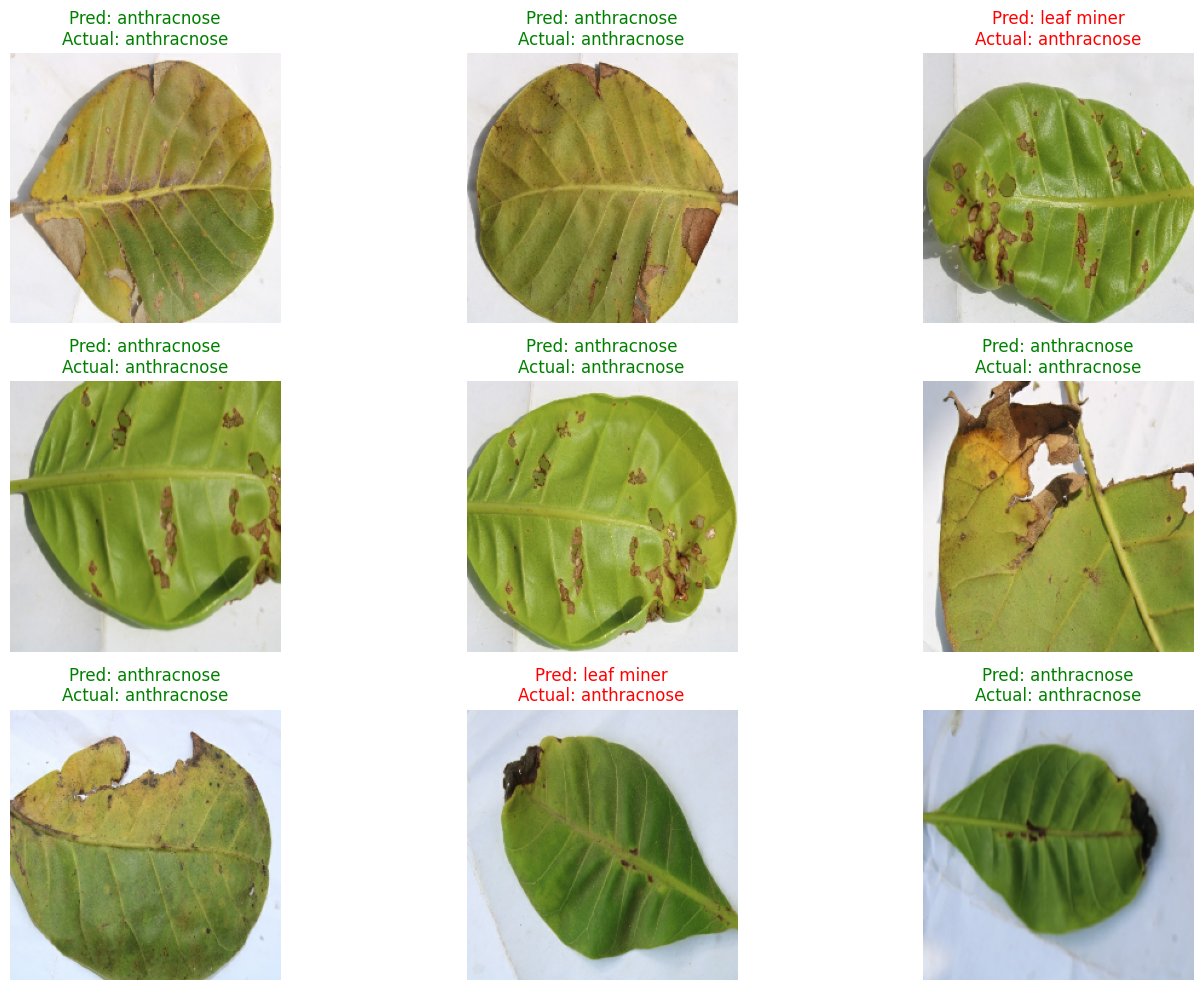

In [ ]:
import numpy as np

# Load a random batch from the test dataset
for images, labels in test_dataset.take(1):
    # Make predictions
    predictions = model.predict(images)
    predicted_classes = np.argmax(predictions, axis=1)

    # Plot some results
    plt.figure(figsize=(15, 10))
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))

        actual_class = class_names[labels[i]]
        predicted_class = class_names[predicted_classes[i]]

        color = "green" if actual_class == predicted_class else "red"

        plt.title(f"Pred: {predicted_class}\nActual: {actual_class}", color=color)
        plt.axis("off")

    plt.tight_layout()
    plt.show()

In [8]:
from IPython.display import display, Javascript
from google.colab.output import eval_js
from base64 import b64decode
import cv2
import numpy as np

def take_photo(filename='photo.jpg', quality=0.8):
    js = Javascript('''
        async function takePhoto(quality) {
          const div = document.createElement('div');
          const capture = document.createElement('button');
          capture.textContent = '📸 Take Photo';
          div.appendChild(capture);

          const video = document.createElement('video');
          video.style.display = 'block';
          const stream = await navigator.mediaDevices.getUserMedia({video: true});

          document.body.appendChild(div);
          div.appendChild(video);
          video.srcObject = stream;
          await video.play();

          google.colab.output.setIframeHeight(document.documentElement.scrollHeight, true);

          await new Promise((resolve) => capture.onclick = resolve);

          const canvas = document.createElement('canvas');
          canvas.width = video.videoWidth;
          canvas.height = video.videoHeight;
          canvas.getContext('2d').drawImage(video, 0, 0);

          stream.getTracks().forEach(track => track.stop());
          div.remove();

          return canvas.toDataURL('image/jpeg', quality);
        }
    ''')
    display(js)
    data = eval_js('takePhoto({})'.format(quality))
    binary = b64decode(data.split(',')[1])
    with open(filename, 'wb') as f:
        f.write(binary)
    return filename

In [9]:
image_path = take_photo()
print("Saved to:", image_path)

<IPython.core.display.Javascript object>

MessageError: NotAllowedError: Permission denied

In [10]:
image_path = take_photo()
print("Saved to:", image_path)

<IPython.core.display.Javascript object>

Saved to: photo.jpg


In [11]:
img = tf.keras.utils.load_img(image_path, target_size=(224, 224))
img_array = tf.keras.utils.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)

prediction = model.predict(img_array)

class_names = ['anthracnose', 'gumosis', 'healthy', 'leaf miner', 'red rust']

print("Prediction:", class_names[np.argmax(prediction)])

NameError: name 'tf' is not defined